<a href="https://colab.research.google.com/github/mdonbruce/AspNetDocs/blob/master/Module6_TreeModelsInAction_CODELAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 6 CODELAB — Tree Models in Action
## From Lines to Trees: Choosing the Right Regression Model


In [10]:
import os
# os.chdir("/mnt/data") # This line is removed as /mnt/data does not exist
print("Working directory:", os.getcwd())

Working directory: /content


## 1) Setup


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

print("Ready ✅")


Ready ✅


## 2) Load data


In [4]:
DATA_PATH = "housing_ensemble_large.csv"
df = pd.read_csv(DATA_PATH)
df.shape, df.head(3)


((50000, 5),
           sqft        age  distance_to_city  rooms          price
 0  2847.699907   0.221640         22.923392      9  666861.547113
 1  2403.214989  30.601811          9.906512      7  622847.427823
 2  2953.381977  73.123942         11.361705      8  673005.290113)

## 3) Split train/test


In [5]:
target = "price"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((40000, 4), (10000, 4))

## 4) Train models


In [6]:
lin = LinearRegression().fit(X_train, y_train)
tree = DecisionTreeRegressor(max_depth=6, random_state=42).fit(X_train, y_train)
forest = RandomForestRegressor(n_estimators=60, max_depth=14, random_state=42, n_jobs=-1).fit(X_train, y_train)

print("Trained ✅")


Trained ✅


## 5) Evaluate + overfitting gap


In [7]:
def metrics(model):
    p_tr = model.predict(X_train)
    p_te = model.predict(X_test)
    out = {
        "MAE_train": mean_absolute_error(y_train, p_tr),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, p_tr)),
        "R2_train": r2_score(y_train, p_tr),
        "MAE_test": mean_absolute_error(y_test, p_te),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, p_te)),
        "R2_test": r2_score(y_test, p_te),
    }
    out["RMSE_gap"] = out["RMSE_test"] - out["RMSE_train"]
    return out

results = pd.DataFrame({
    "Linear": metrics(lin),
    "Tree(depth=6)": metrics(tree),
    "Forest(60)": metrics(forest)
}).T

results.sort_values("RMSE_test")


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,RMSE_gap
Linear,12136.829141,15220.780458,0.987191,12129.670785,15147.614971,0.987356,-73.165486
Forest(60),7581.580958,9491.484917,0.995019,12688.047546,15907.147133,0.986056,6415.662216
Tree(depth=6),20953.826101,26205.373893,0.962033,21421.953241,26921.367452,0.960061,715.993559


## 6) Residual plot (best model)


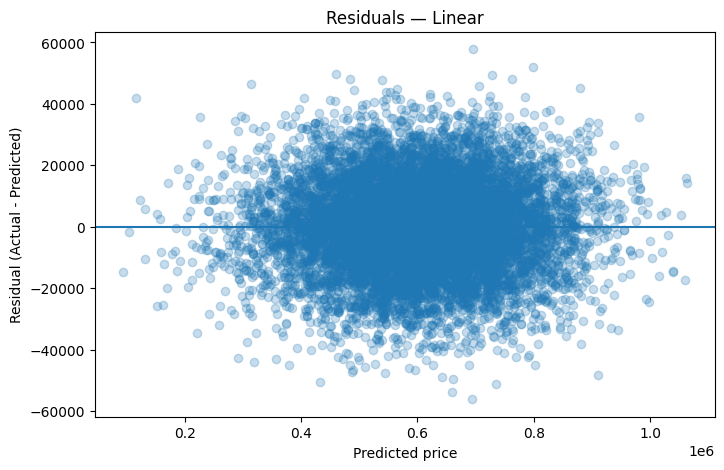

In [8]:
best = results.sort_values("RMSE_test").index[0]
best_model = {"Linear": lin, "Tree(depth=6)": tree, "Forest(60)": forest}[best]

pred = best_model.predict(X_test)
resid = y_test - pred

plt.figure(figsize=(8,5))
plt.scatter(pred, resid, alpha=0.25)
plt.axhline(0)
plt.title(f"Residuals — {best}")
plt.xlabel("Predicted price")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()


## 7) Feature importance (forest)


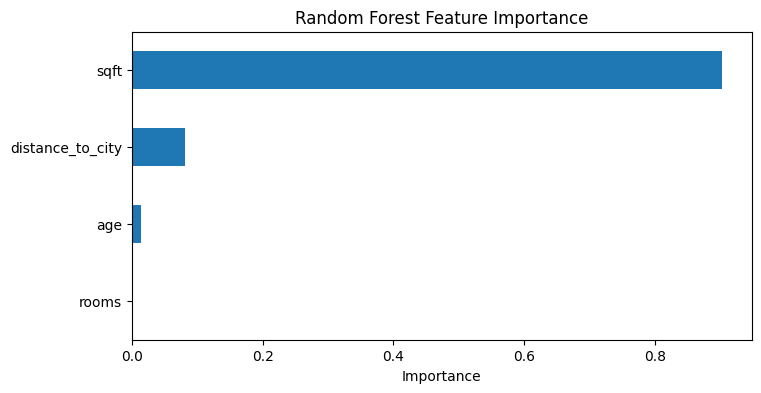

,0
sqft,0.903452
distance_to_city,0.081368
age,0.014623
rooms,0.000558


In [9]:
importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8,4))
importances.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

importances.sort_values(ascending=False).head(8)
